In [1]:
import sys
from pathlib import Path

ROOT = str(Path.cwd().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_all_datasets
from src.preprocessing import (
    add_rul_column,
    add_binary_label,
    drop_useless_columns,
    normalize_sensors,
    preprocess_train,
    preprocess_test,
)
from src.feature_engineering import build_features
from src.config import (
    DATASETS,
    USEFUL_SENSORS,
    PROCESSED_DIR,
    MAX_RUL,
    CLASSIFICATION_W,
    WINDOW_SIZE,
)

data = load_all_datasets()

In [2]:
processed = {}

for ds_id in DATASETS:
    train_raw, test_raw, rul = data[ds_id]

    train = preprocess_train(train_raw)
    test = preprocess_test(test_raw, rul)

    print(f"\n{ds_id} — Train: {train.shape} | Test: {test.shape}")
    print(f"  RUL range train: [{train['rul'].min()}, {train['rul'].max()}]")
    print(f"  Label balance train: {train['label'].value_counts().to_dict()}")
    print(f"  RUL range test: [{test['rul'].min()}, {test['rul'].max()}]")

    processed[ds_id] = {"train": train, "test": test, "rul": rul}


FD001 — Train: (20631, 20) | Test: (100, 20)
  RUL range train: [0, 125]
  Label balance train: {0: 17531, 1: 3100}
  RUL range test: [7, 145]

FD002 — Train: (53759, 20) | Test: (259, 20)
  RUL range train: [0, 125]
  Label balance train: {0: 45699, 1: 8060}
  RUL range test: [6, 194]

FD003 — Train: (24720, 20) | Test: (100, 20)
  RUL range train: [0, 125]
  Label balance train: {0: 21620, 1: 3100}
  RUL range test: [6, 145]

FD004 — Train: (61249, 20) | Test: (248, 20)
  RUL range train: [0, 125]
  Label balance train: {0: 53530, 1: 7719}
  RUL range test: [6, 195]


In [3]:
for ds_id in DATASETS:
    train = processed[ds_id]["train"]
    processed[ds_id]["train"] = build_features(train, window=WINDOW_SIZE)
    print(f"{ds_id} — Features después de engineering: {processed[ds_id]['train'].shape[1]} columnas")

FD001 — Features después de engineering: 62 columnas
FD002 — Features después de engineering: 62 columnas
FD003 — Features después de engineering: 62 columnas
FD004 — Features después de engineering: 62 columnas


In [4]:
sample = processed["FD001"]["train"]
new_cols = [c for c in sample.columns if "roll_mean" in c or "roll_std" in c or "trend" in c]
print(f"Features nuevas: {len(new_cols)}")
print(f"Ejemplos: {new_cols[:6]}")
sample[["unit_id", "cycle", "sensor_11", "sensor_11_roll_mean", "sensor_11_roll_std", "sensor_11_trend"]].head(10)

Features nuevas: 42
Ejemplos: ['sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean', 'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std']


,unit_id,cycle,sensor_11,sensor_11_roll_mean,sensor_11_roll_std,sensor_11_trend
0,1,1,47.47,47.470000,0.000000,0.000000
1,1,2,47.49,47.480000,0.014142,0.010000
2,1,3,47.27,47.410000,0.121655,-0.070000
3,1,4,47.13,47.340000,0.171659,-0.070000
4,1,5,47.28,47.328000,0.151063,-0.012000
5,1,6,47.16,47.300000,0.151526,-0.028000
6,1,7,47.36,47.308571,0.140170,0.008571
7,1,8,47.24,47.300000,0.132017,-0.008571
8,1,9,47.29,47.298889,0.123536,-0.001111
9,1,10,47.03,47.272000,0.144207,-0.026889


In [5]:
for ds_id in DATASETS:
    train = processed[ds_id]["train"]
    test = processed[ds_id]["test"]

    sensor_cols = [c for c in train.columns if c.startswith("sensor_")]

    train_norm, test_norm, scaler = normalize_sensors(train, test)

    processed[ds_id]["train_norm"] = train_norm
    processed[ds_id]["test_norm"] = test_norm
    processed[ds_id]["scaler"] = scaler

    print(f"{ds_id} — Normalizado. Train min/max sensor_11: {train_norm['sensor_11'].min():.3f} / {train_norm['sensor_11'].max():.3f}")

FD001 — Normalizado. Train min/max sensor_11: 0.000 / 1.000
FD002 — Normalizado. Train min/max sensor_11: 0.000 / 1.000
FD003 — Normalizado. Train min/max sensor_11: 0.000 / 1.000
FD004 — Normalizado. Train min/max sensor_11: 0.000 / 1.000


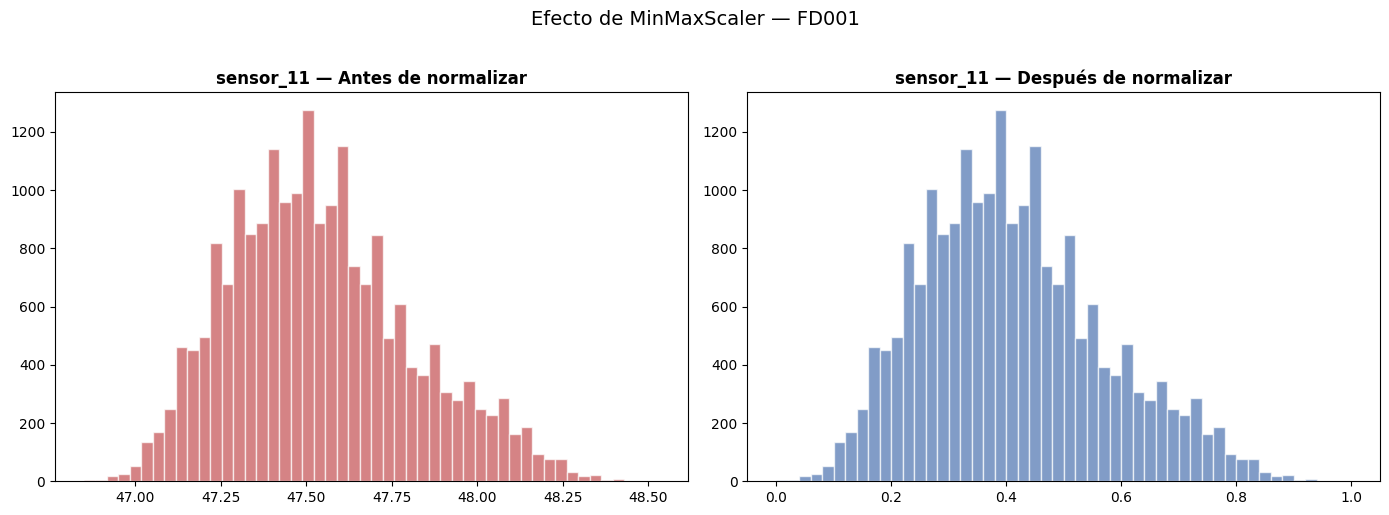

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ds_id = "FD001"
train_raw = processed[ds_id]["train"]
train_norm = processed[ds_id]["train_norm"]

axes[0].hist(train_raw["sensor_11"], bins=50, alpha=0.7, color="#C44E52", edgecolor="white")
axes[0].set_title("sensor_11 — Antes de normalizar", fontsize=12, fontweight="bold")

axes[1].hist(train_norm["sensor_11"], bins=50, alpha=0.7, color="#4C72B0", edgecolor="white")
axes[1].set_title("sensor_11 — Después de normalizar", fontsize=12, fontweight="bold")

plt.suptitle("Efecto de MinMaxScaler — FD001", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
exclude_cols = {"unit_id", "cycle", "rul", "label"}

feature_cols = {}
for ds_id in DATASETS:
    cols = [c for c in processed[ds_id]["train_norm"].columns if c not in exclude_cols]
    feature_cols[ds_id] = cols
    print(f"{ds_id} — {len(cols)} features para modelado")

feature_cols["FD001"][:10]

FD001 — 58 features para modelado
FD002 — 58 features para modelado
FD003 — 58 features para modelado
FD004 — 58 features para modelado


['op_setting_1',
 'op_setting_2',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12']

In [8]:
for ds_id in DATASETS:
    train_path = PROCESSED_DIR / f"train_{ds_id}.parquet"
    test_path = PROCESSED_DIR / f"test_{ds_id}.parquet"

    processed[ds_id]["train_norm"].to_parquet(train_path, index=False)
    processed[ds_id]["test_norm"].to_parquet(test_path, index=False)

    print(f"✓ {ds_id} guardado — Train: {train_path.name} | Test: {test_path.name}")

✓ FD001 guardado — Train: train_FD001.parquet | Test: test_FD001.parquet
✓ FD002 guardado — Train: train_FD002.parquet | Test: test_FD002.parquet
✓ FD003 guardado — Train: train_FD003.parquet | Test: test_FD003.parquet
✓ FD004 guardado — Train: train_FD004.parquet | Test: test_FD004.parquet


In [9]:
for f in sorted(PROCESSED_DIR.glob("*.parquet")):
    df = pd.read_parquet(f)
    print(f"{f.name}: {df.shape}")

test_FD001.parquet: (100, 20)
test_FD002.parquet: (259, 20)
test_FD003.parquet: (100, 20)
test_FD004.parquet: (248, 20)
train_FD001.parquet: (20631, 62)
train_FD002.parquet: (53759, 62)
train_FD003.parquet: (24720, 62)
train_FD004.parquet: (61249, 62)


In [10]:
import json

meta = {
    "feature_cols": feature_cols,
    "max_rul": MAX_RUL,
    "classification_w": CLASSIFICATION_W,
    "window_size": WINDOW_SIZE,
}

meta_path = PROCESSED_DIR / "metadata.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"✓ Metadata guardado en {meta_path}")

✓ Metadata guardado en C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\data\processed\metadata.json


In [11]:
print("=" * 60)
print("  PIPELINE DE PREPROCESAMIENTO COMPLETO")
print("=" * 60)
for ds_id in DATASETS:
    tr = processed[ds_id]["train_norm"]
    te = processed[ds_id]["test_norm"]
    n_feat = len(feature_cols[ds_id])
    print(f"  {ds_id}: Train {tr.shape[0]:>6,} × {n_feat} feat | Test {te.shape[0]:>4} × {n_feat} feat")
print(f"\n  RUL cap: {MAX_RUL}")
print(f"  Ventana rolling: {WINDOW_SIZE}")
print(f"  Umbral clasificación: {CLASSIFICATION_W}")
print(f"  Archivos guardados en: {PROCESSED_DIR}")
print("=" * 60)

  PIPELINE DE PREPROCESAMIENTO COMPLETO
  FD001: Train 20,631 × 58 feat | Test  100 × 58 feat
  FD002: Train 53,759 × 58 feat | Test  259 × 58 feat
  FD003: Train 24,720 × 58 feat | Test  100 × 58 feat
  FD004: Train 61,249 × 58 feat | Test  248 × 58 feat

  RUL cap: 125
  Ventana rolling: 30
  Umbral clasificación: 30
  Archivos guardados en: C:\Users\OEM\Desktop\Proyectos personales\NASA_C-MAPSS_Data\data\processed
